# Model Evolution 
### The punchline plots in the chapter/paper

In [1]:
import os
import sys
import pickle
import argparse
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import loguniform

sys.path.insert(1, 'scripts')
sys.path.insert(1, 'stella')

import stella

/Users/azib/micromamba/envs/nets2/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/azib/.lightkurve/cache. Please move all the files in the legacy directory /Users/azib/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


## Load dataset

In [2]:
with open("../datasets/comets.pkl", "rb") as file:
    ds = pickle.load(file)

In [3]:
data = ds['dataset']

In [4]:
cnn = stella.ConvNN(
    output_dir='../cnn-models/',ds=data)

---
## Test on lightcurves

In [5]:
import lightkurve as lk
import stella

In [6]:
os.makedirs('punchline-plots/',exist_ok=True)
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_model_evolution(target, models, titles, sector=None, mission='TESS', pipeline='TESS-SPOC', figsize=(10,18)):
    """
    Plot the evolution of model predictions across different training iterations.
    
    Parameters
    ----------
    target : str
        Target name (e.g., "Beta Pic")
    models : list
        List of paths to different model iterations
    titles : list
        List of titles describing each model iteration
    sector : int, optional
        Specific sector to analyse. Also used as the Campaign/Quarter for Kepler
    mission : str, optional
        Mission name (default: 'TESS')
    pipeline : str, optional
        Pipeline name (default: 'TESS-SPOC')
    figsize : tuple, optional
        Figure size (default: (15, 12))
    """

    plt.close('all')
    plt.clf()
    
    # Download and process lightcurve
    if sector is None:
        lc = lk.search_lightcurve(target, mission=mission, author=pipeline)[0].download()
    elif mission != 'TESS':
        lc = lk.search_lightcurve(target, quarter=sector, mission=mission).download()
        lc = lc[lc.sap_quality == 0]
    else:
        lc = lk.search_lightcurve(target, sector=sector, mission=mission, author=pipeline).download()
        lc = lc[lc.quality.value == 0]
    
    # Process the flux
    f = np.array((lc.flux.value / np.nanmedian(lc.flux.value)) - 1)
    f = np.array(f / np.nanstd((lc.flux.value / np.nanmedian(lc.flux.value)) - 1))
    f = f + 1
    f = f[~np.isnan(f)]
    f = (f - np.min(f)) / (np.max(f) - np.min(f))
    
    # Align arrays
    min_len = min(len(lc.time.value), len(f), len(lc.flux_err.value))
    times = lc.time.value[:min_len]
    fluxes = f[:min_len]
    errs = lc.flux_err.value[:min_len]
    
    # Create subplot grid
    fig, axes = plt.subplots(len(models), 1, figsize=figsize,sharex=True)
    plt.style.use('seaborn-v0_8-paper')
    fig.suptitle(f'Model Evolution for {target}', fontsize=16, y=0.995)
    
    # Plot each model's predictions
    for i, (model_path, title, ax) in enumerate(zip(models, titles, axes)):
        cnn.predict(modelname=model_path, times=times, fluxes=fluxes, errs=errs)
        
        scatter = ax.scatter(cnn.predict_time[0], cnn.predict_flux[0], 
                           c=cnn.predictions[0], vmin=0, vmax=1, s=5,
                           cmap='viridis')
        ax.grid(False)
        # Add colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='2%', pad=0.05)
        plt.colorbar(scatter, cax=cax, label='Probability')
        
        # Customize subplot
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Time (BJD - 2457000)' if i == len(models)-1 else '',fontsize=12)
        ax.set_ylabel('Normalised Flux',fontsize=12)
        
    plt.tight_layout()
    #plt.savefig(f'punchline-plots/{target}.png',dpi=300,bbox_inches='tight')
    plt.show()
    return fig


In [49]:
models = [
    '../cnn-models/ensemble_s0101_i0200_b0.63.h5',
    '../cnn-models/ensemble_s0011_i0200_b0.7.h5',
    '../cnn-models/ensemble_s0121_i0200_b0.72.h5',
    '../cnn-models/ensemble_s0131_i0200_b0.35.h5',
    '../cnn-models/ensemble_s0144_i0200_b0.43.h5',
    '../cnn-models/ensemble_s0994_i0200_b0.49.h5',
    '../cnn-models/ensemble_s0990_i0200_b0.56.h5',
    '../cnn-models/ensemble_s0997_i0200_b0.49.h5',
    '../archive/cnn-models-es/ensemble_s1045_i0200_b0.63.h5'
]

titles = [
    'Stage 1: Comets vs Non-comets',
    'Stage 2: Stage 1 + Augmented Data',
    'Stage 3: Stage 2 + Planets & Binaries',
    'Stage 4: Stage 3 (but larger dataset for class balance)',
    'Stage 5: Stage 4 + Sines',
    'Stage 6a: Three-Layer CNN (with Stage 4 dataset)',
    'Stage 6b: Three-layer CNN (with Stage 5 dataset)',
    'Stage 7a: CNN-RNN hybrid (with Stage 4 dataset)',
    'Stage 7b: CNN-RNN hybrid (with Stage 5 dataset)'
]

<Figure size 640x440 with 0 Axes>

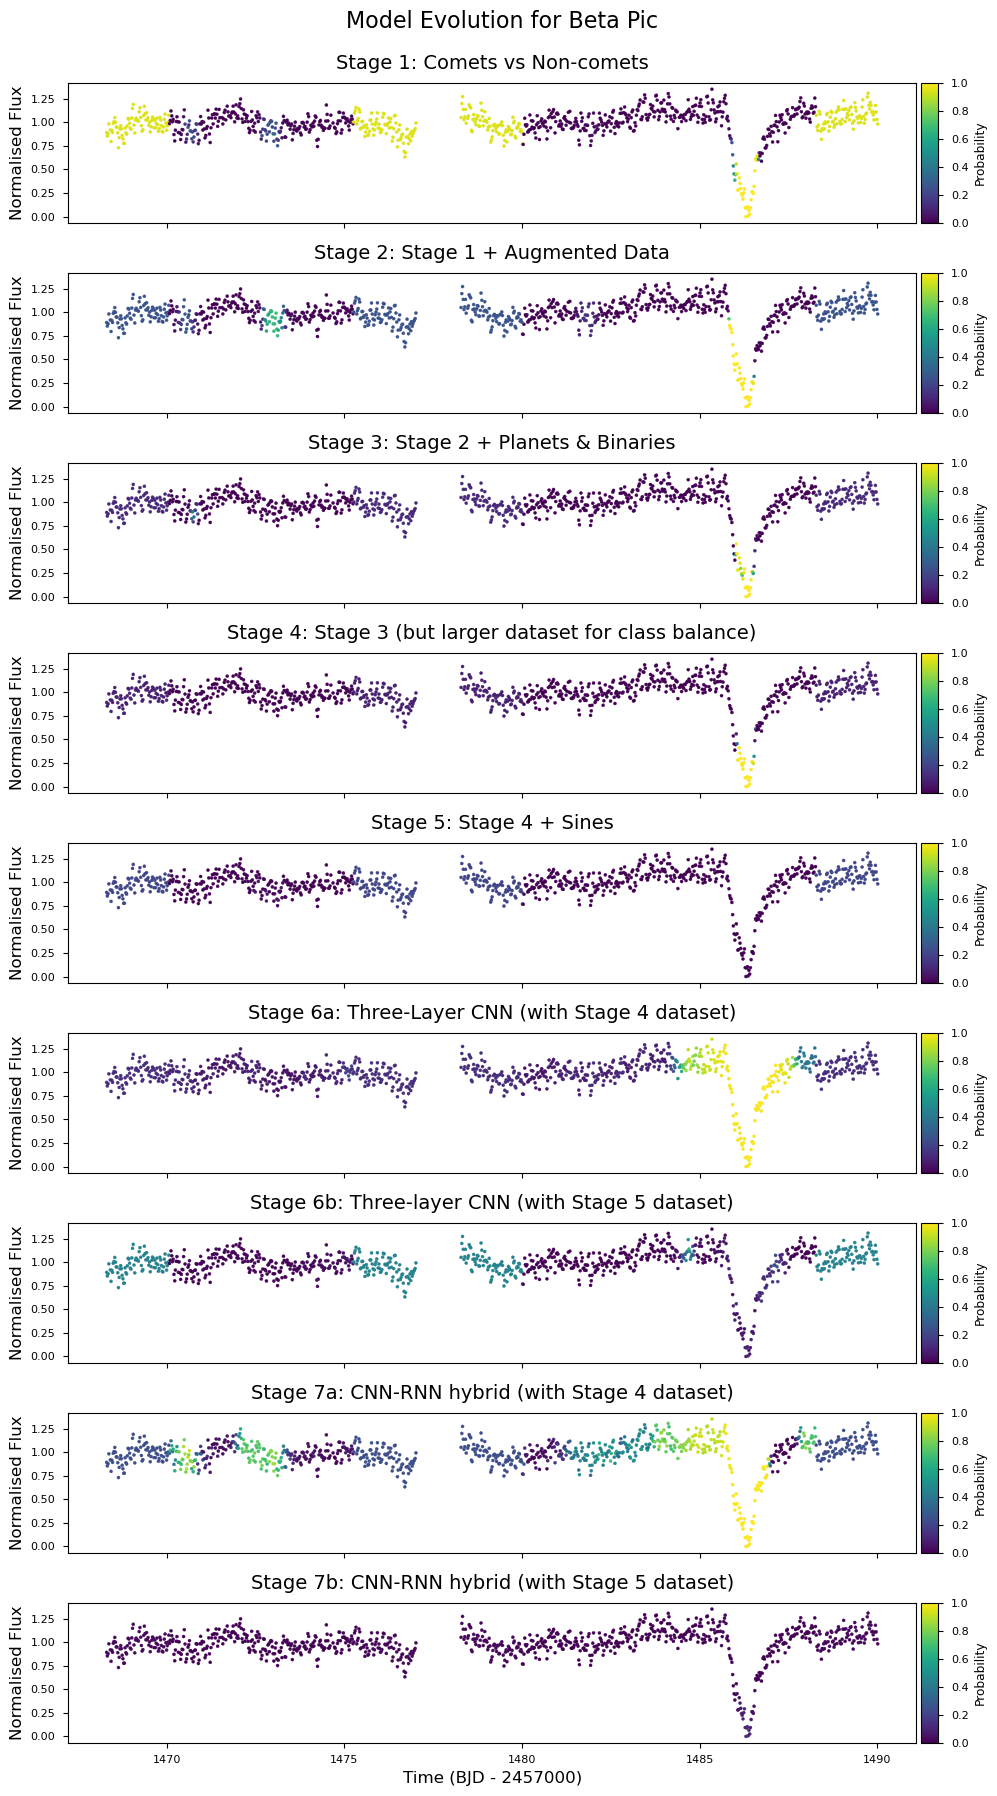

In [50]:
fig = plot_model_evolution('Beta Pic', models, titles,sector=6)
plt.show()

<Figure size 640x440 with 0 Axes>

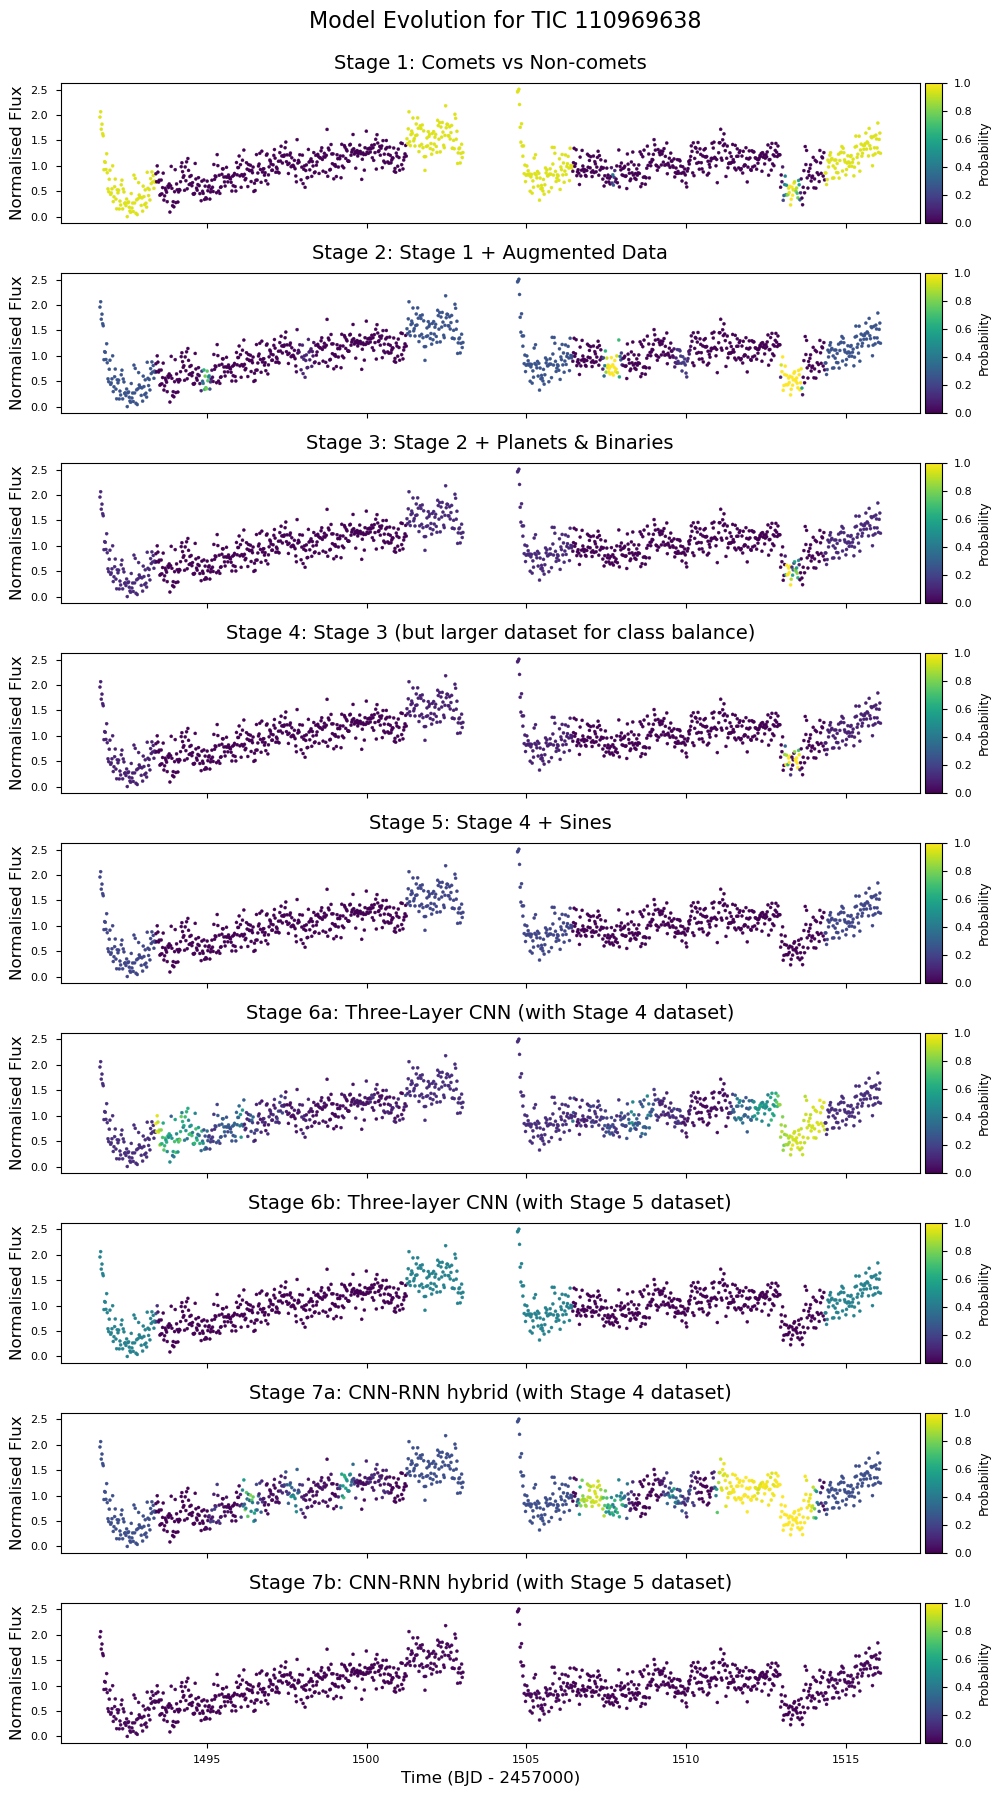

In [51]:
fig = plot_model_evolution('TIC 110969638', models, titles,pipeline='QLP')
plt.show()

<Figure size 640x440 with 0 Axes>

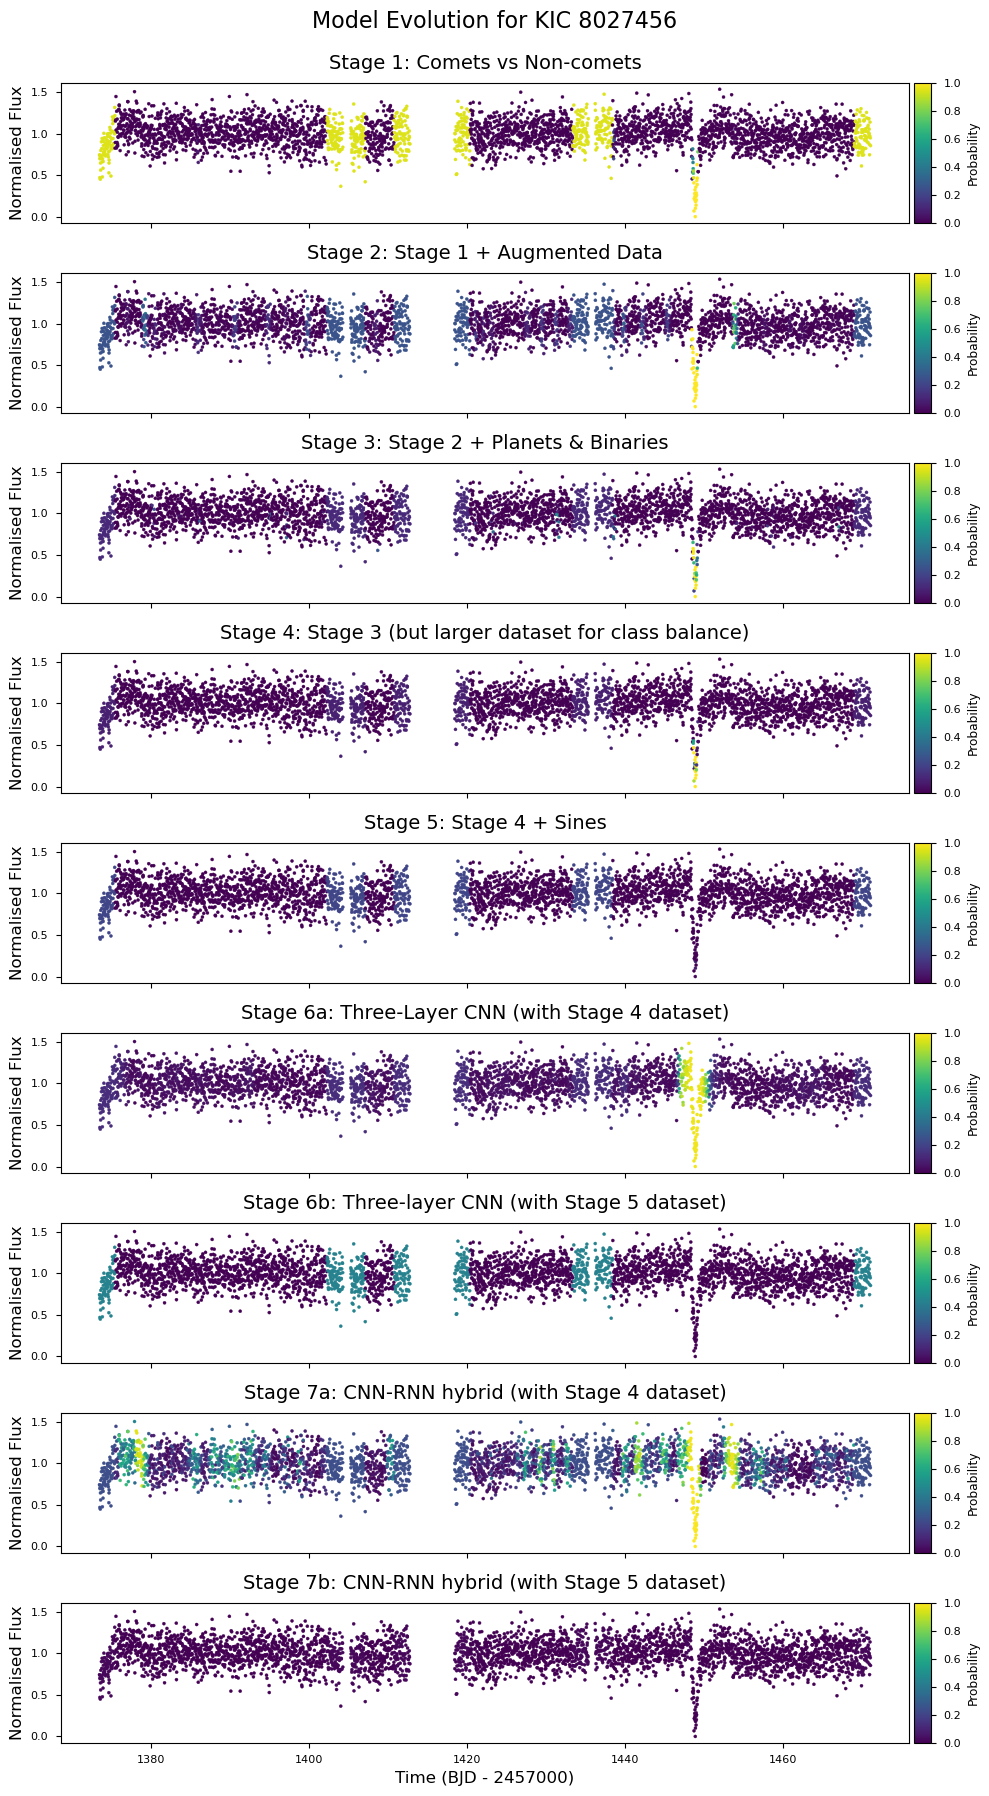

In [52]:
plot_model_evolution('KIC 8027456', models, titles, mission='Kepler',sector=15,pipeline='Kepler')
plt.show()

<Figure size 640x440 with 0 Axes>

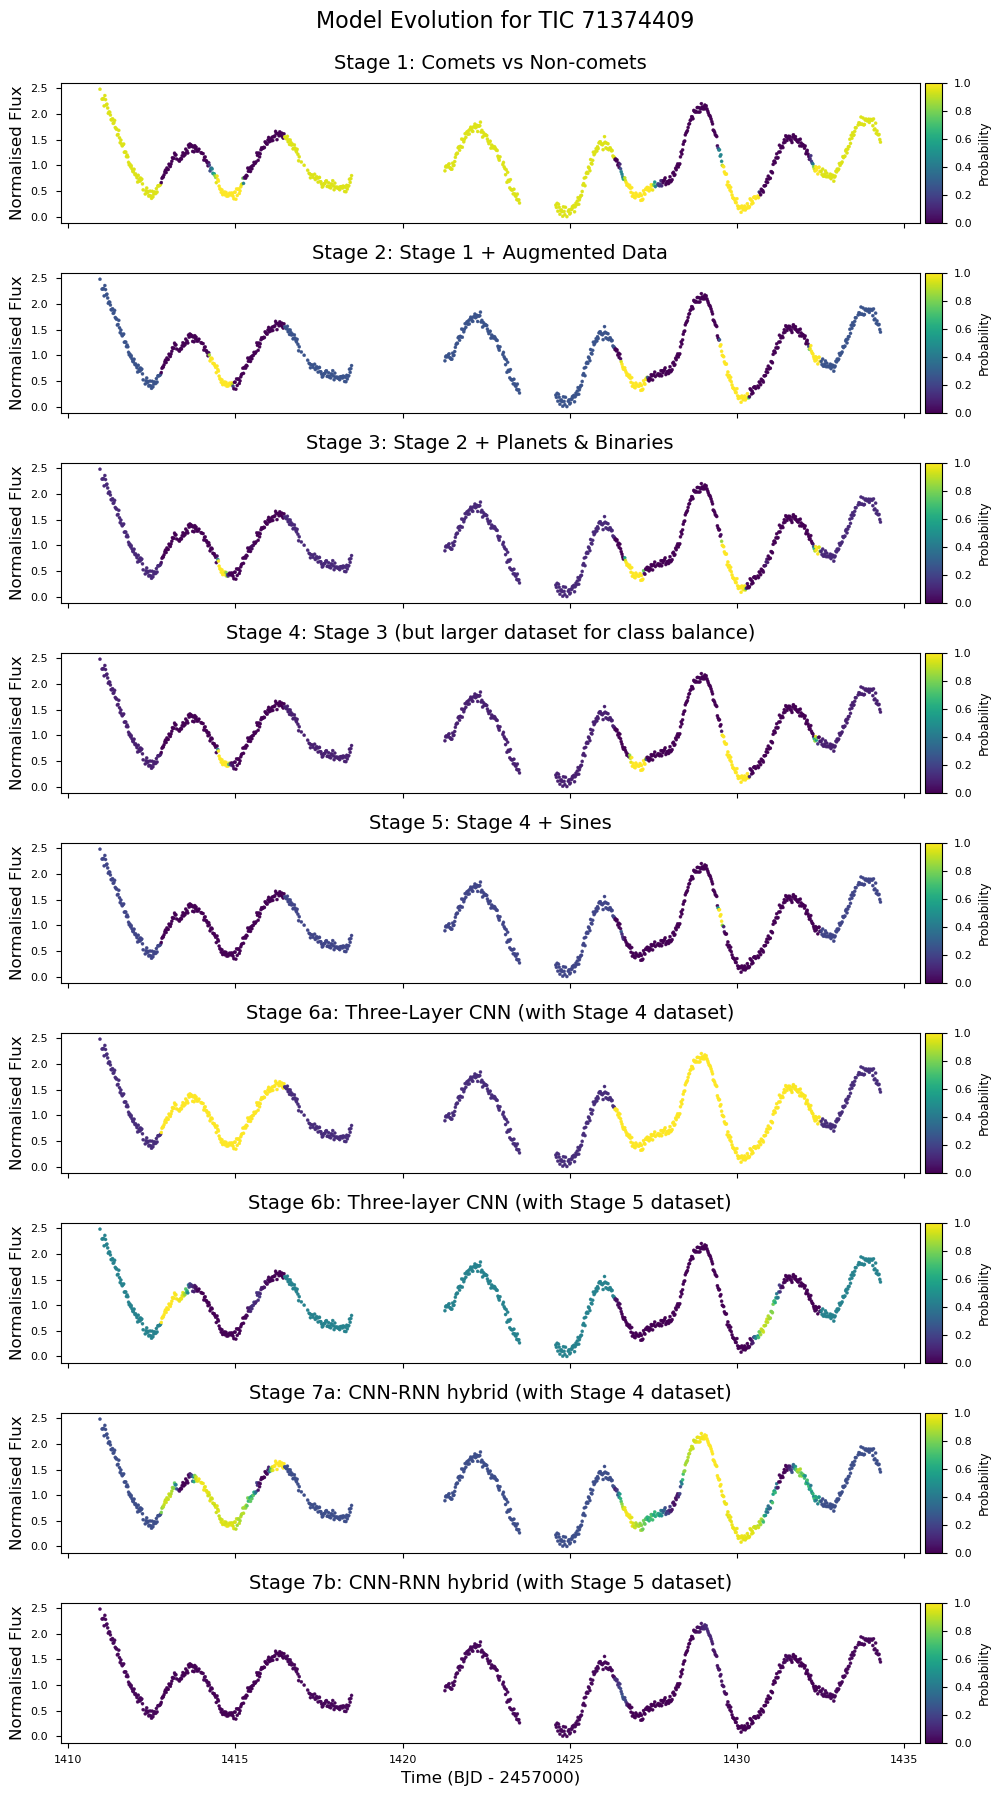

In [53]:
plot_model_evolution('TIC 71374409',models, titles)
plt.show()

<Figure size 640x440 with 0 Axes>

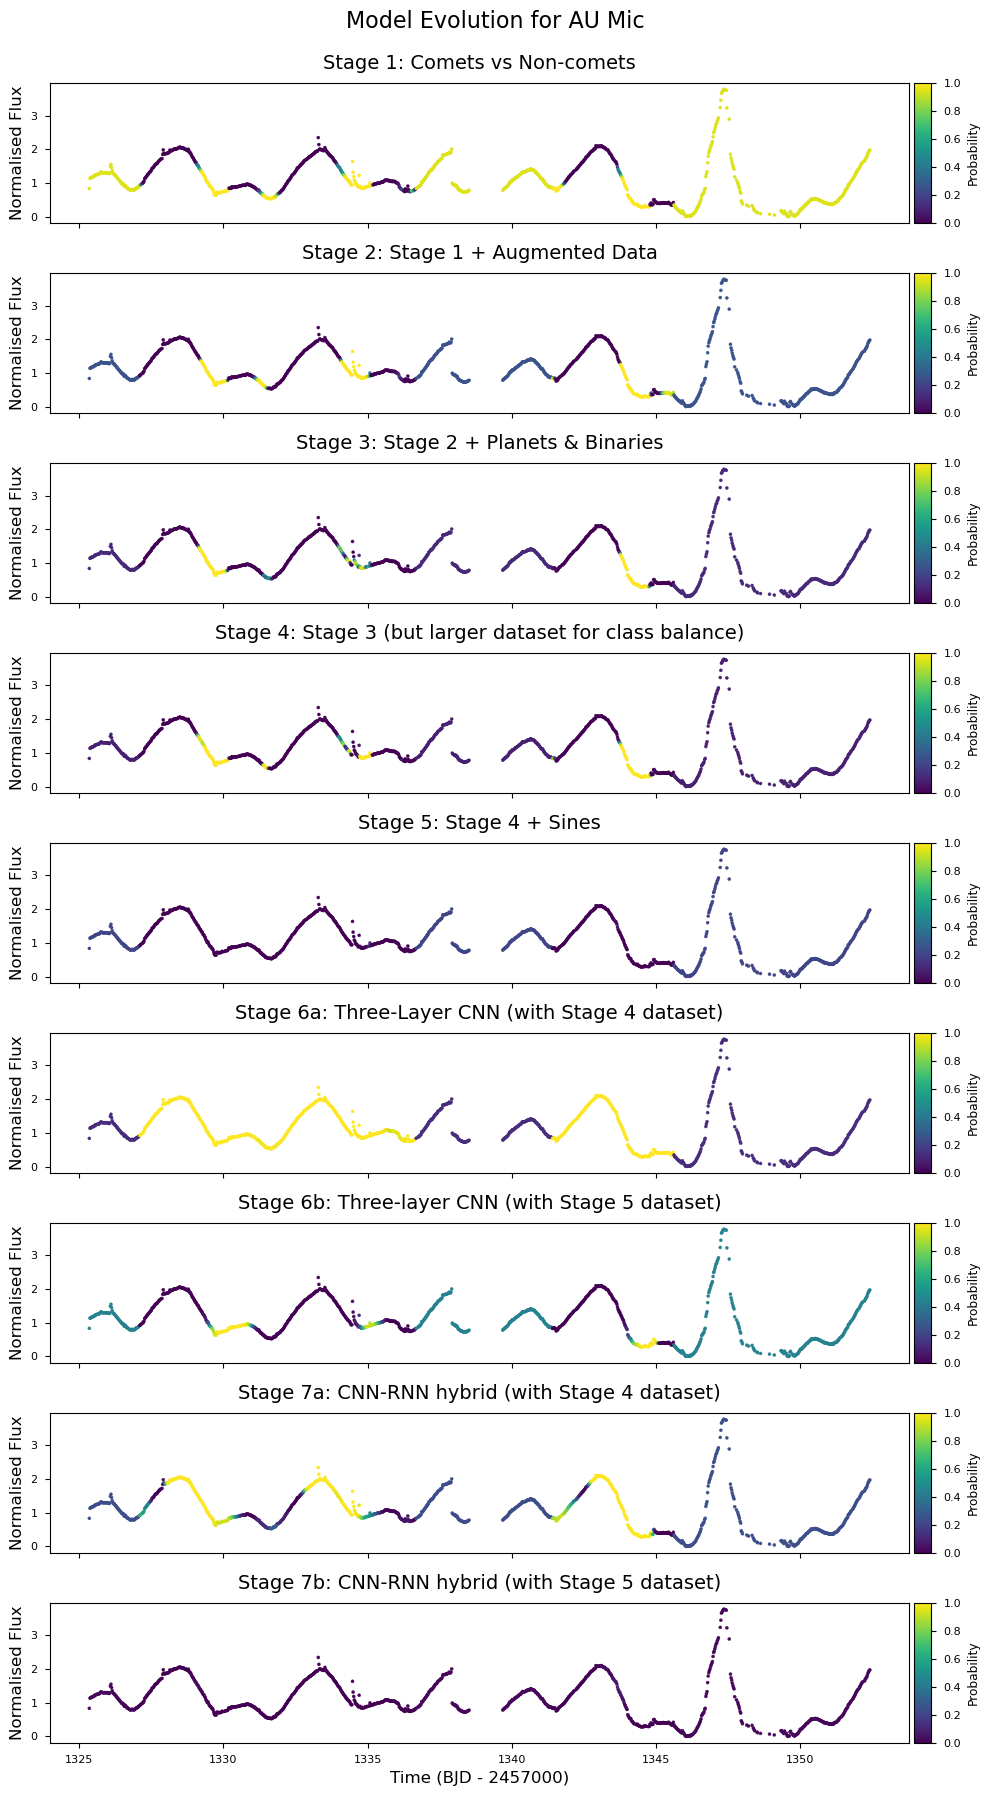

In [54]:
plot_model_evolution('AU Mic', models, titles)
plt.show()

<Figure size 640x440 with 0 Axes>

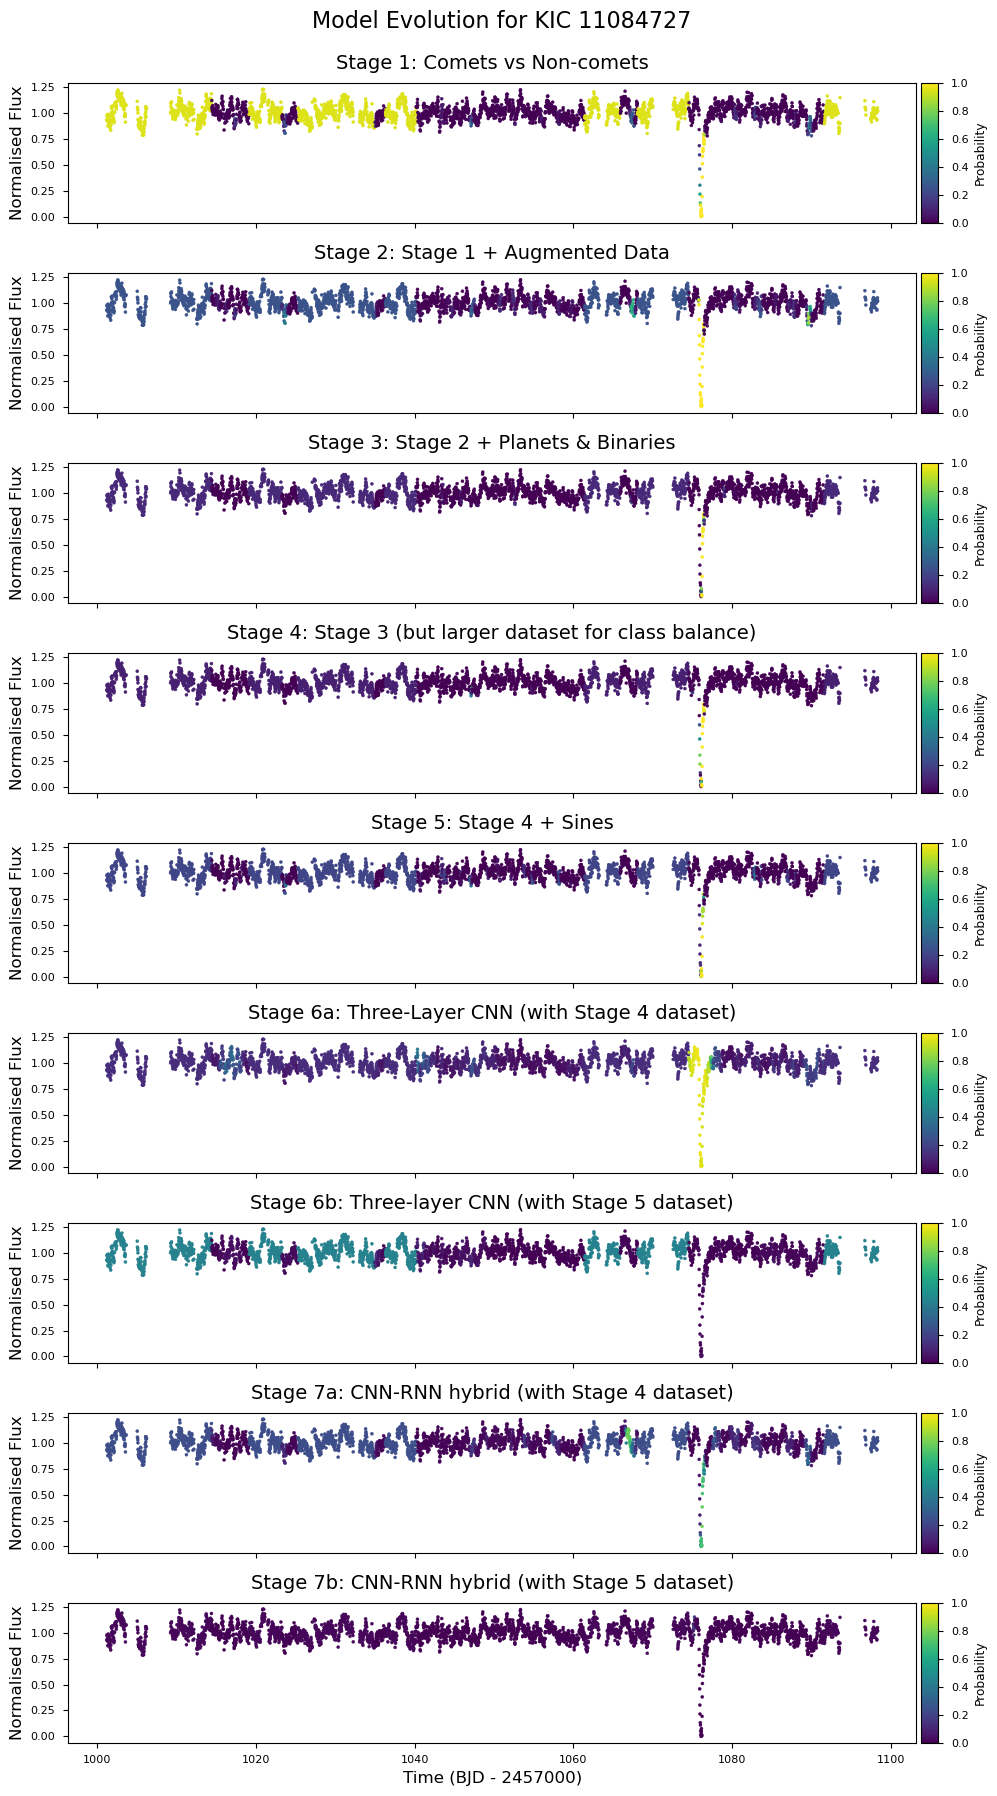

In [55]:
plot_model_evolution('KIC 11084727', models, titles, mission='Kepler',sector=11,pipeline='Kepler')
plt.show()

---

In [26]:
from keras.models import load_model


In [30]:
load = cnn.load_model('../cnn-models/ensemble_s0994_i0200_b0.49.h5')

157/157 [==============================] - 0s 2ms/step


In [41]:
dir(cnn.model.layers[0])

['_TF_MODULE_IGNORED_PROPERTIES',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_activity_regularizer',
 '_add_trackable',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_auto_config',
 '_auto_get_config',
 '_auto_track_sub_layers',
 '_autocast',
 '_autographed_call',
 '_batch_input_shape',
 '_build_input_shape',
 '_call_spec',
 '_callable_losses',
 '_captured_weight_regularizer',
 '_cast_single_input',
 '_channels_first',
 '_checkpoint_dependencies',
 '_clear_losses',
 '_compute_causal_padding',
 '_compute_dtype',
 '_compute_dtype_object',
 '_dedup_weights',
 '_deferred_dependencies',
 '_delete_trackin